# Notebook 05 — Tích hợp dữ liệu (Integration)

**Nhóm:** La Gia Hân (24520448) · Huỳnh Gia Hào (24520457)  
**Môn:** DS108 — Tiền Xử Lý Dữ Liệu  

---

## Mục tiêu

Tích hợp 4 bộ dữ liệu đã làm sạch (1 NSMO + 3 Weather) thành **1 bộ dữ liệu thống nhất** phục vụ bài toán dự báo phụ tải điện ngắn hạn.

Thách thức kỹ thuật chính là **sự bất đồng tần suất**:  
- NSMO: 30 phút/mẫu → ~52,608 dòng  
- Weather: 1 giờ/mẫu → ~26,304 dòng/thành phố  

Để merge được, weather phải được **nội suy lên 30 phút** trước.

---

## Vị trí trong Medallion Architecture

Theo kiến trúc **Bronze → Silver → Gold** (Medallion Architecture):
- **Bronze**: raw batch files từ crawl (notebooks 01–02)
- **Silver**: cleaned files sau notebook 04 (`*_v1_clean.csv`) ← *input của notebook này*
- **Gold (bước này)**: `unified_v1_merged.csv` — dữ liệu đã tích hợp, nhất quán, sẵn sàng cho feature engineering

> **Nguyên tắc Immutable History**: notebook này **không sửa** các file Silver đầu vào. Mọi biến đổi chỉ tạo output mới.

## Pipeline

```
Input (4 file)
  nsmo_v1_clean.csv        (30 phút)
  hanoi_v1_clean.csv       (1 giờ)
  danang_v1_clean.csv      (1 giờ)
  hcm_v1_clean.csv         (1 giờ)
         ↓
[Bước 1] Nội suy weather 1h → 30 phút
         ↓
[Bước 2] Rename cột weather thêm hậu tố miền
         ↓
[Bước 3] Outer merge NSMO + 3 weather
         ↓
[Bước 4] Validation
         ↓
Output: unified_v1_merged.csv
```

## 0. Import & Cấu hình

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import random
from pathlib import Path

#  Tự động chuyển working directory về root repo
# Notebook nằm ở notebooks/ nhưng data/ nằm ở root → cần cd lên 1 cấp
# Logic: tìm thư mục cha chứa folder 'data/' thì đó là root
def find_repo_root(start: Path, marker: str = 'data') -> Path:
    """Leo ngược cây thư mục cho đến khi tìm thấy thư mục chứa `marker`."""
    current = start.resolve()
    for _ in range(5):  # tối đa leo 5 cấp
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError(
        f'Không tìm thấy thư mục "{marker}/" trong vòng 5 cấp từ {start}. '
        f'Kiểm tra lại cấu trúc repo.'
    )

REPO_ROOT = find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
print(f'Working directory: {Path.cwd()}')

#  Paths (tương đối từ root)
PROCESSED_DIR = Path('data/processed')
REPORTS_DIR   = Path('reports/integration')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

#  Sanity check: data/processed/ phải tồn tại
assert PROCESSED_DIR.exists(), (
    f'Không tìm thấy {PROCESSED_DIR.resolve()}. '
    f'Đảm bảo notebook 04 đã chạy xong.'
)

#  Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

#  Seed để spot-check tái hiện được
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print('Setup xong.')
print(f'Processed dir : {PROCESSED_DIR.resolve()}')
print(f'Reports dir   : {REPORTS_DIR.resolve()}')

Working directory: C:\Users\ASUS\DS108-Project
Setup xong.
Processed dir : C:\Users\ASUS\DS108-Project\data\processed
Reports dir   : C:\Users\ASUS\DS108-Project\reports\integration


## 1. Đọc dữ liệu đầu vào

In [2]:
#  Hàm tiện ích: đọc file processed
def load_processed(filename: str, time_col: str = 'Timestamp') -> pd.DataFrame:
    """
    Đọc file CSV từ data/processed, parse datetime và set index.
    Trả về DataFrame với DatetimeIndex để resample/merge dễ dàng.
    """
    path = PROCESSED_DIR / filename
    df = pd.read_csv(path, encoding='utf-8-sig', parse_dates=[time_col])
    df = df.sort_values(time_col).reset_index(drop=True)
    print(f'  [{filename}]  {df.shape[0]:,} dòng × {df.shape[1]} cột '
          f'| {df[time_col].min()} → {df[time_col].max()}')
    return df

print('Đọc dữ liệu...')
nsmo   = load_processed('nsmo_v1_clean.csv',   time_col='Timestamp')
hanoi  = load_processed('hanoi_v1_clean.csv',  time_col='Timestamp')
danang = load_processed('danang_v1_clean.csv', time_col='Timestamp')
hcm    = load_processed('hcm_v1_clean.csv',    time_col='Timestamp')

Đọc dữ liệu...
  [nsmo_v1_clean.csv]  52,608 dòng × 9 cột | 2023-03-11 00:30:00 → 2026-03-11 00:00:00
  [hanoi_v1_clean.csv]  26,304 dòng × 12 cột | 2023-03-11 00:00:00 → 2026-03-10 23:00:00
  [danang_v1_clean.csv]  26,304 dòng × 12 cột | 2023-03-11 00:00:00 → 2026-03-10 23:00:00
  [hcm_v1_clean.csv]  26,304 dòng × 12 cột | 2023-03-11 00:00:00 → 2026-03-10 23:00:00


In [3]:
#  Kiểm tra nhanh cột của từng file weather # Cột kỳ vọng sau notebook 04EXPECTED_WEATHER_COLS = [    'Timestamp', 'temp', 'feelslike', 'humidity', 'precip',    'precipprob', 'windspeed', 'cloudcover', 'solarradiation',    'uvindex', 'conditions', 'icon']for name, df in [('hanoi', hanoi), ('danang', danang), ('hcm', hcm)]:    missing_cols = [c for c in EXPECTED_WEATHER_COLS if c not in df.columns]    extra_cols   = [c for c in df.columns if c not in EXPECTED_WEATHER_COLS]    status = '[OK] OK' if not missing_cols else f'[ERROR] Thiếu: {missing_cols}'    print(f'{name}: {status}' + (f' | Extra: {extra_cols}' if extra_cols else ''))print()print('Cột NSMO:', list(nsmo.columns))

## 2. Nội suy Weather 1 giờ → 30 phút

### Lý do chọn kỹ thuật

NSMO có tần suất 30 phút, weather có tần suất 1 giờ. Để join được chính xác theo `Timestamp`, cần điền giá trị tại các mốc còn thiếu (`:30` của mỗi giờ).

**Numeric** (`temp`, `humidity`, `precip`, ...): dùng **`resample + interpolate('linear')`**  
→ Các đại lượng vật lý như nhiệt độ, độ ẩm thay đổi liên tục và đều theo thời gian trong khoảng 1 giờ — nội suy tuyến tính là xấp xỉ hợp lý, đơn giản, không đưa ra thông tin "bịa".

**Categorical** (`conditions`, `icon`): dùng **`resample + ffill()`**  
→ Không thể "nội suy" giữa 2 nhãn rời rạc (vd: "Rain" và "Clear"). Giả định trạng thái thời tiết không thay đổi đột ngột trong 30 phút là hợp lý về mặt khí tượng.

> **Lưu ý:** `resample` yêu cầu `DatetimeIndex` — ta set index trước khi resample, rồi reset sau.

In [4]:
#  Định nghĩa nhóm cột
NUMERIC_WEATHER_COLS = [
    'temp', 'feelslike', 'humidity', 'precip',
    'precipprob', 'windspeed', 'cloudcover',
    'solarradiation', 'uvindex'
]
CATEGORICAL_WEATHER_COLS = ['conditions', 'icon']


def upsample_weather_to_30min(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    """
    Nội suy weather DataFrame từ 1 giờ lên 30 phút.

    Quy trình:
    1. Set DatetimeIndex trên cột Timestamp
    2. Resample toàn bộ cột về 30min (tạo ra các hàng NaN tại :30)
    3. Numeric → interpolate('linear'): điền bằng trung gian tuyến tính
    4. Categorical → ffill(): điền bằng giá trị giờ trước đó
    5. Reset index, đổi tên index về 'Timestamp'
    """
    df = df.copy()

    # Chỉ lấy cột cần thiết
    cols_keep = ['Timestamp'] + NUMERIC_WEATHER_COLS + CATEGORICAL_WEATHER_COLS
    cols_keep = [c for c in cols_keep if c in df.columns]
    df = df[cols_keep].set_index('Timestamp')

    # Resample về 30 phút (tạo skeleton với NaN tại :30)
    df_30 = df.resample('30min').asfreq()

    # Numeric: nội suy tuyến tính
    num_cols = [c for c in NUMERIC_WEATHER_COLS if c in df_30.columns]
    df_30[num_cols] = df_30[num_cols].interpolate(method='linear')

    # Categorical: forward fill
    cat_cols = [c for c in CATEGORICAL_WEATHER_COLS if c in df_30.columns]
    df_30[cat_cols] = df_30[cat_cols].ffill()

    df_30 = df_30.reset_index().rename(columns={'index': 'Timestamp'})

    # Kiểm tra kết quả
    n_null = df_30.isnull().sum().sum()
    print(f'  [{source_name}] {len(df):,} hàng → {len(df_30):,} hàng sau upsample '
          f'| NaN còn lại: {n_null}')

    return df_30


print('Nội suy weather 1h → 30min...')
hanoi_30  = upsample_weather_to_30min(hanoi,  'hanoi')
danang_30 = upsample_weather_to_30min(danang, 'danang')
hcm_30    = upsample_weather_to_30min(hcm,    'hcm')

Nội suy weather 1h → 30min...
  [hanoi] 26,304 hàng → 52,607 hàng sau upsample | NaN còn lại: 0
  [danang] 26,304 hàng → 52,607 hàng sau upsample | NaN còn lại: 0
  [hcm] 26,304 hàng → 52,607 hàng sau upsample | NaN còn lại: 0


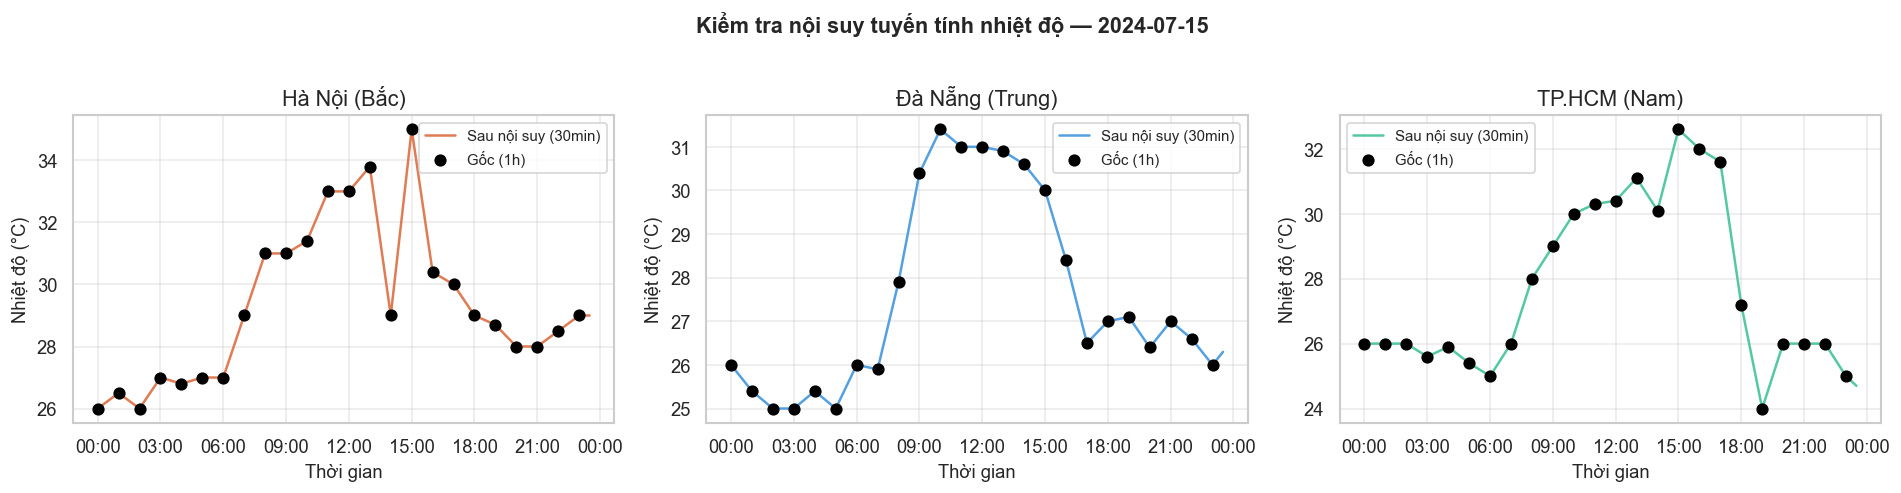

Đã lưu: reports/integration/interpolation_check_temp.png


In [5]:
#  Kiểm tra trực quan nội suy: vẽ 1 ngày sample
# Chọn 1 ngày ngẫu nhiên trong tháng 7 (mùa hè, nhiệt độ biến động rõ)
sample_date = '2024-07-15'

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (raw_df, up_df, city, color) in zip(
    axes,
    [
        (hanoi,  hanoi_30,  'Hà Nội (Bắc)',  '#e07b54'),
        (danang, danang_30, 'Đà Nẵng (Trung)', '#54a0e0'),
        (hcm,    hcm_30,   'TP.HCM (Nam)',   '#54c99f'),
    ]
):
    raw_day = raw_df[raw_df['Timestamp'].dt.date == pd.Timestamp(sample_date).date()]
    up_day  = up_df[up_df['Timestamp'].dt.date  == pd.Timestamp(sample_date).date()]

    ax.plot(up_day['Timestamp'],  up_day['temp'],  color=color,
            lw=1.5, label='Sau nội suy (30min)')
    ax.scatter(raw_day['Timestamp'], raw_day['temp'], color='black',
               s=40, zorder=5, label='Gốc (1h)')

    ax.set_title(city)
    ax.set_xlabel('Thời gian')
    ax.set_ylabel('Nhiệt độ (°C)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

fig.suptitle(f'Kiểm tra nội suy tuyến tính nhiệt độ — {sample_date}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'interpolation_check_temp.png',
            bbox_inches='tight', dpi=120)
plt.show()
print('Đã lưu: reports/integration/interpolation_check_temp.png')

**Đọc biểu đồ:** Các điểm đen là giá trị gốc (tần suất 1 giờ). Đường màu là giá trị sau nội suy tuyến tính (tần suất 30 phút). Cần kiểm tra:
- Đường nội suy có nằm hợp lý giữa 2 điểm gốc liên tiếp không?
- Không có giá trị âm hoặc spike bất thường ở mốc `:30` không?

Nếu đường nội suy trông mượt và không có spike → kỹ thuật hoạt động đúng.

## 3. Rename cột — thêm hậu tố miền

Sau khi merge 3 weather vào cùng 1 bảng, các cột trùng tên (`temp`, `humidity`, ...) phải được phân biệt theo miền.  
Quy ước:
- `hanoi` → `_North`  
- `danang` → `_Central`  
- `hcm` → `_South`

In [6]:
def rename_weather_cols(df: pd.DataFrame, suffix: str) -> pd.DataFrame:
    """
    Đổi tên các cột weather (không phải Timestamp) sang dạng col_SUFFIX.
    VD: temp → temp_North
    """
    rename_map = {
        col: f'{col}{suffix}'
        for col in df.columns
        if col != 'Timestamp'
    }
    return df.rename(columns=rename_map)


hanoi_30  = rename_weather_cols(hanoi_30,  '_North')
danang_30 = rename_weather_cols(danang_30, '_Central')
hcm_30    = rename_weather_cols(hcm_30,    '_South')

print('Cột Hanoi sau rename:', list(hanoi_30.columns))
print('Cột Danang sau rename:', list(danang_30.columns))
print('Cột HCM sau rename:', list(hcm_30.columns))

Cột Hanoi sau rename: ['Timestamp', 'temp_North', 'feelslike_North', 'humidity_North', 'precip_North', 'precipprob_North', 'windspeed_North', 'cloudcover_North', 'solarradiation_North', 'uvindex_North', 'conditions_North', 'icon_North']
Cột Danang sau rename: ['Timestamp', 'temp_Central', 'feelslike_Central', 'humidity_Central', 'precip_Central', 'precipprob_Central', 'windspeed_Central', 'cloudcover_Central', 'solarradiation_Central', 'uvindex_Central', 'conditions_Central', 'icon_Central']
Cột HCM sau rename: ['Timestamp', 'temp_South', 'feelslike_South', 'humidity_South', 'precip_South', 'precipprob_South', 'windspeed_South', 'cloudcover_South', 'solarradiation_South', 'uvindex_South', 'conditions_South', 'icon_South']


## 4. Merge: NSMO + 3 Weather

### Lý do dùng outer join

Dù cả 4 nguồn đều đã được làm sạch và kỳ vọng cùng khoảng thời gian, vẫn có thể tồn tại **lệch pha nhỏ** ở đầu/cuối chuỗi (vd: NSMO bắt đầu từ `00:30` còn weather bắt đầu từ `00:00`). Outer join giữ lại **toàn bộ dòng** từ tất cả nguồn để:
1. Không vô tình mất dữ liệu
2. NaN sau merge trở thành tín hiệu rõ ràng để kiểm tra và xử lý

Sau khi validate, nếu NaN chỉ nằm ở rìa (đầu/cuối) thì chấp nhận được.

In [7]:
print('Merge dữ liệu...')

# Bước 1: Merge NSMO với weather Hà Nội (Bắc)
unified = pd.merge(
    nsmo,
    hanoi_30,
    on='Timestamp',
    how='outer'
)
print(f'  Sau merge NSMO + Hanoi:  {unified.shape[0]:,} dòng × {unified.shape[1]} cột')

# Bước 2: Merge thêm weather Đà Nẵng (Trung)
unified = pd.merge(
    unified,
    danang_30,
    on='Timestamp',
    how='outer'
)
print(f'  Sau merge + Danang:      {unified.shape[0]:,} dòng × {unified.shape[1]} cột')

# Bước 3: Merge thêm weather TP.HCM (Nam)
unified = pd.merge(
    unified,
    hcm_30,
    on='Timestamp',
    how='outer'
)
print(f'  Sau merge + HCM:         {unified.shape[0]:,} dòng × {unified.shape[1]} cột')

# Sort theo Timestamp
unified = unified.sort_values('Timestamp').reset_index(drop=True)

# Drop dòng rìa: weather bắt đầu 00:00, NSMO bắt đầu 00:30
# → outer join tạo ra 1 dòng 00:00 đầu tiên với Load = NaN → drop
first_ts = unified['Timestamp'].iloc[0]
if pd.isna(unified.loc[unified['Timestamp'] == first_ts, 'Load_National'].values[0]):
    unified = unified.iloc[1:].reset_index(drop=True)
    print(f'  → Dropped dòng rìa {first_ts} (Load = NaN do lệch pha 00:00 vs 00:30)')

print()
print(f'Khoảng thời gian: {unified["Timestamp"].min()} → {unified["Timestamp"].max()}')
print(f'Tổng cột: {list(unified.columns)}')

Merge dữ liệu...
  Sau merge NSMO + Hanoi:  52,609 dòng × 20 cột
  Sau merge + Danang:      52,609 dòng × 31 cột
  Sau merge + HCM:         52,609 dòng × 42 cột
  → Dropped dòng rìa 2023-03-11 00:00:00 (Load = NaN do lệch pha 00:00 vs 00:30)

Khoảng thời gian: 2023-03-11 00:30:00 → 2026-03-11 00:00:00
Tổng cột: ['Timestamp', 'Load_North', 'Load_Central', 'Load_South', 'Load_National', 'Price_North', 'Price_Central', 'Price_South', 'Price_National', 'temp_North', 'feelslike_North', 'humidity_North', 'precip_North', 'precipprob_North', 'windspeed_North', 'cloudcover_North', 'solarradiation_North', 'uvindex_North', 'conditions_North', 'icon_North', 'temp_Central', 'feelslike_Central', 'humidity_Central', 'precip_Central', 'precipprob_Central', 'windspeed_Central', 'cloudcover_Central', 'solarradiation_Central', 'uvindex_Central', 'conditions_Central', 'icon_Central', 'temp_South', 'feelslike_South', 'humidity_South', 'precip_South', 'precipprob_South', 'windspeed_South', 'cloudcover_South

## 5. Validation

Sau khi merge, cần kiểm tra 4 điểm:
1. **Row count**: kỳ vọng ~52,608 dòng (3 năm × 365 ngày × 48 chu kỳ)
2. **NaN check**: số NaN theo từng cột và tổng thể
3. **Duplicate Timestamp**: không được có
4. **Spot-check 5 ngày ngẫu nhiên**: kiểm tra bằng mắt xem dữ liệu có khớp hợp lý không

In [8]:
print('=' * 60)
print('VALIDATION 1 — Row count')
print('=' * 60)

# Kỳ vọng lý thuyết: 3 năm × 365.25 ngày × 48 chu kỳ/ngày
expected_rows = int(3 * 365.25 * 48)
actual_rows   = len(unified)
diff          = actual_rows - expected_rows

print(f'Kỳ vọng lý thuyết : {expected_rows:,} dòng')
print(f'Thực tế           : {actual_rows:,} dòng')
print(f'Chênh lệch        : {diff:+,} dòng')

if abs(diff) <= 200:   # ngưỡng chấp nhận: ~2 ngày dữ liệu
    print('[OK] Row count nằm trong ngưỡng chấp nhận (±200)')
else:
    print(f'[WARNING]  Chênh lệch lớn — cần kiểm tra lại nguồn dữ liệu')

VALIDATION 1 — Row count
Kỳ vọng lý thuyết : 52,596 dòng
Thực tế           : 52,608 dòng
Chênh lệch        : +12 dòng
[OK] Row count nằm trong ngưỡng chấp nhận (±200)


In [9]:
print('=' * 60)
print('VALIDATION 2 — NaN check')
print('=' * 60)

null_counts = unified.isnull().sum()
null_pct    = (null_counts / len(unified) * 100).round(3)

null_summary = pd.DataFrame({
    'Số NaN'    : null_counts,
    'Tỷ lệ (%)' : null_pct
}).loc[null_counts > 0]

if null_summary.empty:
    print('[OK] Không có NaN nào sau merge.')
else:
    print(f'Có {len(null_summary)} cột chứa NaN:')
    print(null_summary.to_string())

    # Phân loại NaN: ở rìa (đầu/cuối) hay giữa chuỗi
    print()
    for col in null_summary.index:
        null_mask  = unified[col].isnull()
        null_rows  = unified[null_mask]
        if not null_rows.empty:
            first_ts = null_rows['Timestamp'].min()
            last_ts  = null_rows['Timestamp'].max()
            data_min = unified['Timestamp'].min()
            data_max = unified['Timestamp'].max()
            edge_gap = pd.Timedelta(hours=2)  # ngưỡng "rìa"
            is_edge  = (first_ts - data_min <= edge_gap) or (data_max - last_ts <= edge_gap)
            loc_note = '(rìa — chấp nhận được)' if is_edge else '(GIỮA chuỗi — cần kiểm tra)'
            print(f'  {col}: {null_counts[col]} NaN | {first_ts} → {last_ts} {loc_note}')

VALIDATION 2 — NaN check
Có 33 cột chứa NaN:
                        Số NaN  Tỷ lệ (%)
temp_North                   2      0.004
feelslike_North              2      0.004
humidity_North               2      0.004
precip_North                 2      0.004
precipprob_North             2      0.004
windspeed_North              2      0.004
cloudcover_North             2      0.004
solarradiation_North         2      0.004
uvindex_North                2      0.004
conditions_North             2      0.004
icon_North                   2      0.004
temp_Central                 2      0.004
feelslike_Central            2      0.004
humidity_Central             2      0.004
precip_Central               2      0.004
precipprob_Central           2      0.004
windspeed_Central            2      0.004
cloudcover_Central           2      0.004
solarradiation_Central       2      0.004
uvindex_Central              2      0.004
conditions_Central           2      0.004
icon_Central                 2 

In [10]:
print('=' * 60)
print('VALIDATION 3 — Duplicate Timestamp')
print('=' * 60)

dup_count = unified['Timestamp'].duplicated().sum()
if dup_count == 0:
    print('[OK] Không có Timestamp trùng lặp.')
else:
    print(f'[ERROR] Có {dup_count} Timestamp trùng lặp — cần xử lý!')
    # Hiển thị 5 dòng đầu
    dup_mask = unified['Timestamp'].duplicated(keep=False)
    print(unified[dup_mask][['Timestamp']].head(10))

    # Tự động drop duplicate (giữ lại first)
    unified = unified.drop_duplicates(subset=['Timestamp'], keep='first')
    print(f'→ Đã drop duplicate, còn {len(unified):,} dòng.')

VALIDATION 3 — Duplicate Timestamp
[OK] Không có Timestamp trùng lặp.


In [11]:
print('=' * 60)
print('VALIDATION 4 — Spot-check 5 ngày ngẫu nhiên')
print('=' * 60)

# Lấy danh sách ngày unique
all_dates = unified['Timestamp'].dt.date.unique()
# Bỏ 1 ngày đầu và cuối để tránh rìa
sample_dates = random.sample(list(all_dates[2:-2]), 5)
sample_dates.sort()

print(f'5 ngày được chọn: {[str(d) for d in sample_dates]}')
print()

# Các cột kiểm tra: 1 từ mỗi nguồn
check_cols = [
    'Timestamp',
    'Load_North', 'Load_South',        # NSMO
    'temp_North', 'temp_South',        # Weather numeric
    'conditions_North', 'icon_South',  # Weather categorical
]
check_cols = [c for c in check_cols if c in unified.columns]

for d in sample_dates:
    day_df = unified[unified['Timestamp'].dt.date == d]
    n_null = day_df[check_cols].isnull().sum().sum()
    print(f'  {d}: {len(day_df)} dòng | NaN trong check_cols: {n_null}')
    # Hiển thị 2 dòng đầu của ngày đó
    display_df = day_df[check_cols].head(2)
    print(display_df.to_string(index=False))
    print()

VALIDATION 4 — Spot-check 5 ngày ngẫu nhiên
5 ngày được chọn: ['2023-05-03', '2023-10-27', '2024-06-12', '2024-07-26', '2024-09-26']

  2023-05-03: 48 dòng | NaN trong check_cols: 0
          Timestamp  Load_North  Load_South  temp_North  temp_South conditions_North          icon_South
2023-05-03 00:00:00     10583.3     12808.0       25.00       30.00 Partially cloudy partly-cloudy-night
2023-05-03 00:30:00     10306.0     12571.9       25.05       29.95 Partially cloudy partly-cloudy-night

  2023-10-27: 48 dòng | NaN trong check_cols: 0
          Timestamp  Load_North  Load_South  temp_North  temp_South conditions_North          icon_South
2023-10-27 00:00:00     14074.4     13790.6       25.00       27.00            Clear partly-cloudy-night
2023-10-27 00:30:00     13695.1     13470.3       24.95       26.95            Clear partly-cloudy-night

  2024-06-12: 48 dòng | NaN trong check_cols: 0
          Timestamp  Load_North  Load_South  temp_North  temp_South conditions_North      

### Validation 5 — Gap check sau merge

Sau outer merge, cần kiểm tra xem chuỗi thời gian có **liên tục** không — tức là không có mốc 30 phút nào bị bỏ trống giữa chừng. Kỹ thuật so sánh `pd.date_range` lý thuyết vs `Timestamp` thực tế (giống notebook 03).

In [12]:
print('=' * 60)
print('VALIDATION 5 — Gap check (chuỗi thời gian liên tục)')
print('=' * 60)

# Tạo chuỗi timestamp lý thuyết từ min đến max, freq 30min
expected_ts = pd.date_range(
    start=unified['Timestamp'].min(),
    end=unified['Timestamp'].max(),
    freq='30min'
)

# So sánh với timestamp thực tế
actual_ts = pd.DatetimeIndex(unified['Timestamp'])
missing_ts = expected_ts.difference(actual_ts)
extra_ts   = actual_ts.difference(expected_ts)

print(f'Timestamp lý thuyết : {len(expected_ts):,} mốc')
print(f'Timestamp thực tế   : {len(actual_ts):,} mốc')
print(f'Thiếu (gap)         : {len(missing_ts):,} mốc')
print(f'Thừa (không khớp)   : {len(extra_ts):,} mốc')

if len(missing_ts) == 0:
    print('[OK] Không có gap — chuỗi thời gian liên tục.')
else:
    print(f'[WARNING]  Có {len(missing_ts)} mốc bị gap. 10 mốc đầu:')
    for ts in missing_ts[:10]:
        print(f'    {ts}')
    # Ghi log ra file để kiểm tra
    gap_log = PROCESSED_DIR / 'unified_gaps_log.txt'
    with open(gap_log, 'w', encoding='utf-8') as f:
        for ts in missing_ts:
            f.write(str(ts) + '\n')
    print(f'→ Đã ghi toàn bộ gaps vào: {gap_log}')

if len(extra_ts) > 0:
    print(f'[WARNING]  Có {len(extra_ts)} timestamp lạ (không khớp 30min grid). 5 đầu:')
    for ts in extra_ts[:5]:
        print(f'    {ts}')

VALIDATION 5 — Gap check (chuỗi thời gian liên tục)
Timestamp lý thuyết : 52,608 mốc
Timestamp thực tế   : 52,608 mốc
Thiếu (gap)         : 0 mốc
Thừa (không khớp)   : 0 mốc
[OK] Không có gap — chuỗi thời gian liên tục.


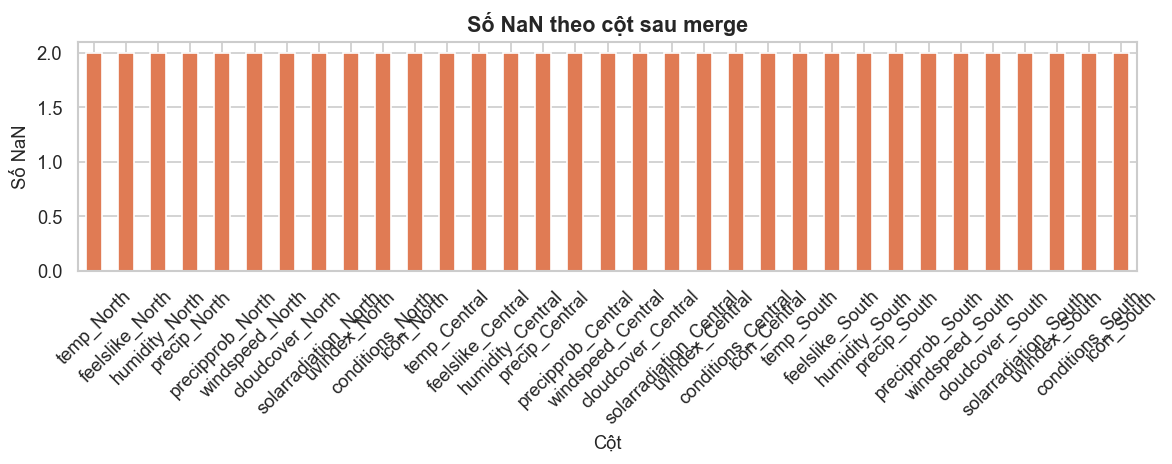

Đã lưu: reports/integration/nan_after_merge.png


In [13]:
#  Vẽ tổng quan NaN heatmap (nếu có NaN)
null_counts = unified.isnull().sum()
cols_with_null = null_counts[null_counts > 0]

if not cols_with_null.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    cols_with_null.sort_values(ascending=False).plot.bar(ax=ax, color='#e07b54')
    ax.set_title('Số NaN theo cột sau merge', fontweight='bold')
    ax.set_xlabel('Cột')
    ax.set_ylabel('Số NaN')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    fig.savefig(REPORTS_DIR / 'nan_after_merge.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Đã lưu: reports/integration/nan_after_merge.png')
else:
    print('Không có NaN — bỏ qua biểu đồ.')

## 6. Vẽ biểu đồ kiểm tra alignment Load vs Temp

Biểu đồ này kiểm tra xem sau khi merge, dữ liệu Load và nhiệt độ có **khớp thời gian** không — đây là bằng chứng trực quan quan trọng trước khi sang EDA.

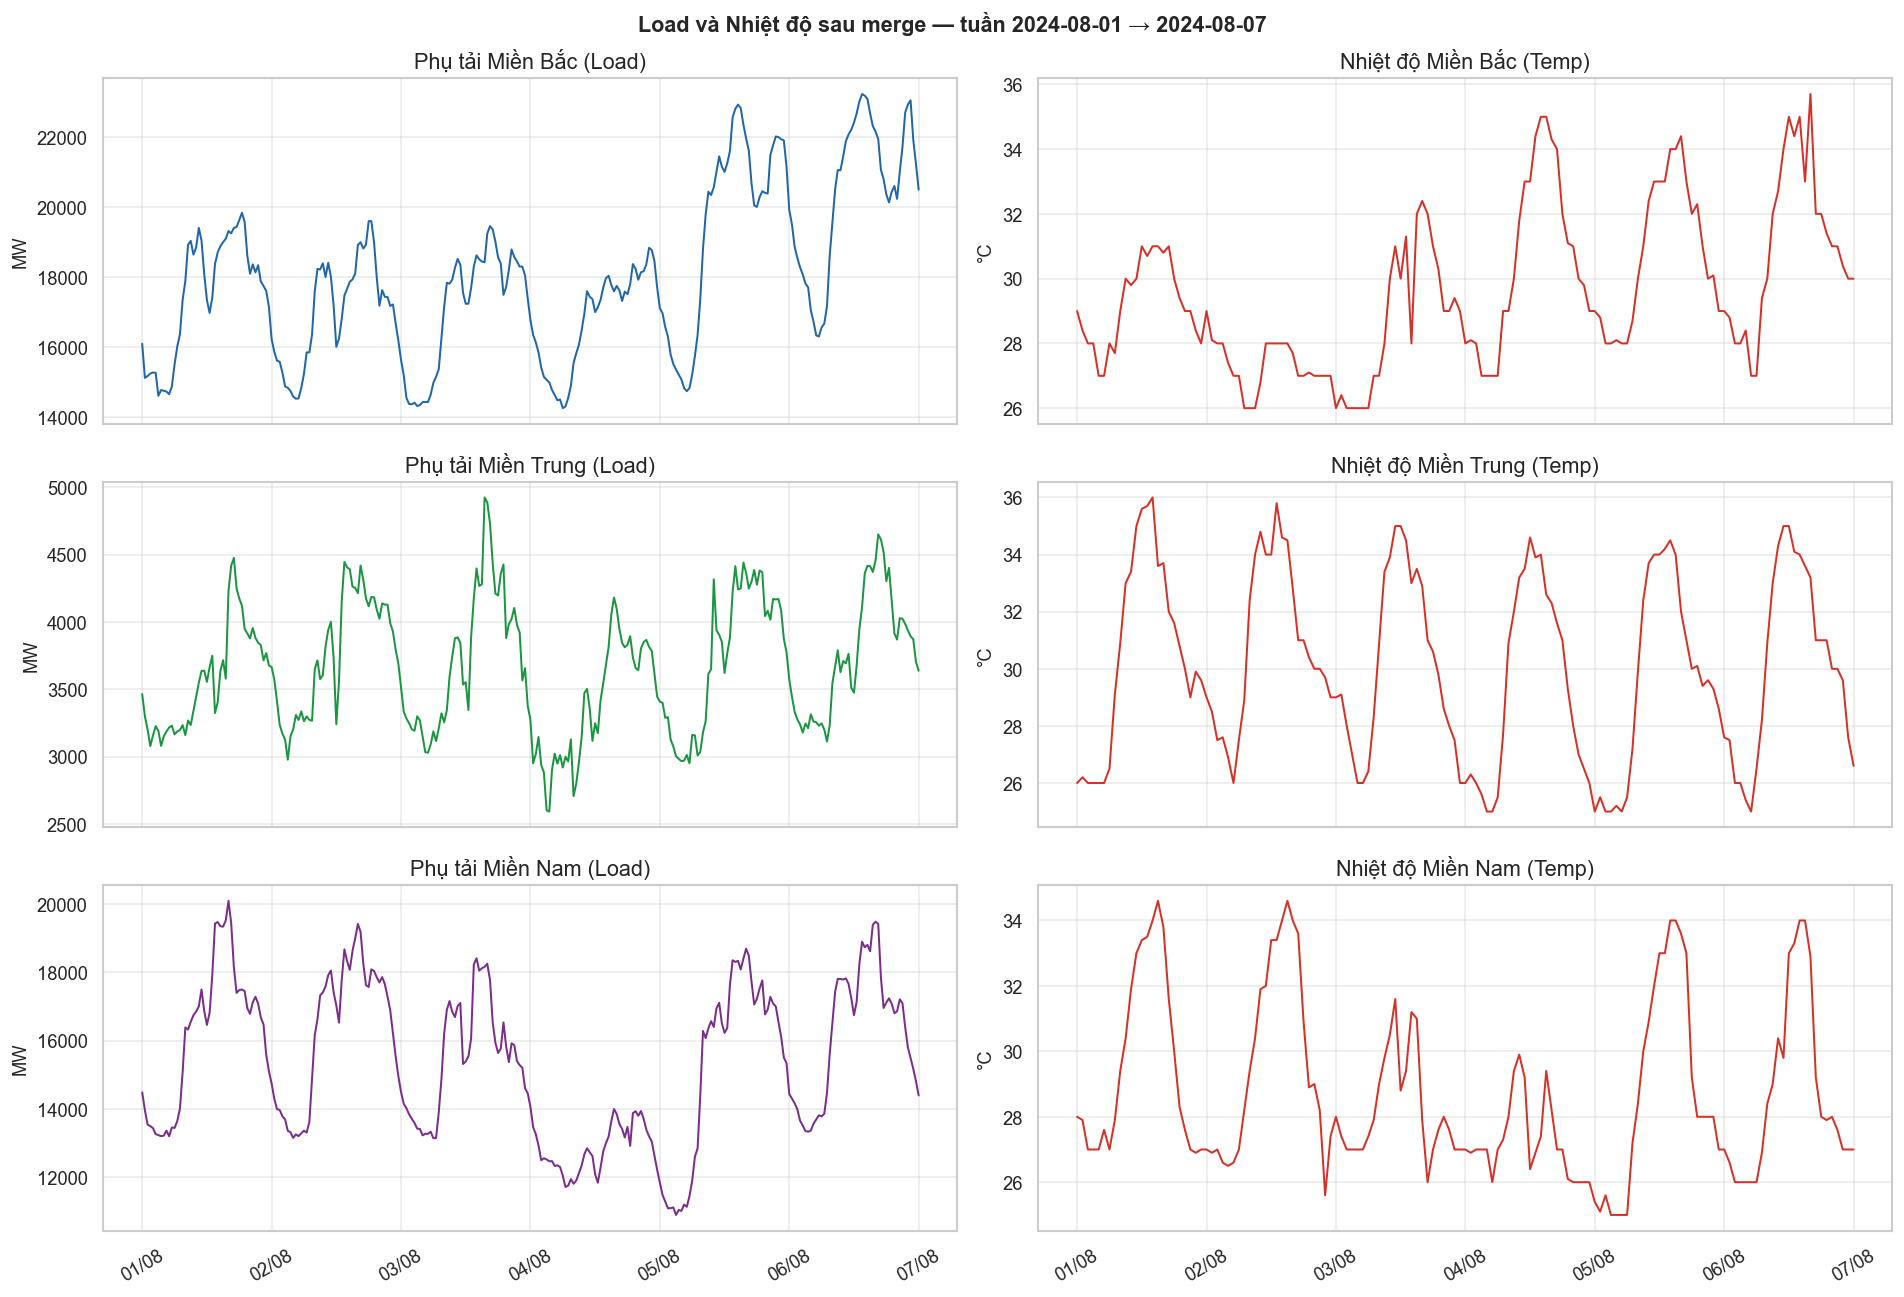

Đã lưu: reports/integration/load_vs_temp_alignment.png


In [14]:
# Chọn 1 tuần sample để vẽ
week_start = '2024-08-01'
week_end   = '2024-08-07'

mask = (unified['Timestamp'] >= week_start) & (unified['Timestamp'] <= week_end)
week = unified[mask].copy()

fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True)

pairs = [
    ('Load_North',   'temp_North',   'Miền Bắc',  '#2166ac', '#d73027'),
    ('Load_Central', 'temp_Central', 'Miền Trung', '#1a9641', '#d73027'),
    ('Load_South',   'temp_South',   'Miền Nam',  '#7b2d8b', '#d73027'),
]

for i, (load_col, temp_col, region, load_color, temp_color) in enumerate(pairs):
    ax_load = axes[i, 0]
    ax_temp = axes[i, 1]

    if load_col in week.columns:
        ax_load.plot(week['Timestamp'], week[load_col],
                     color=load_color, lw=1.2)
        ax_load.set_ylabel('MW')
        ax_load.set_title(f'Phụ tải {region} (Load)')
        ax_load.grid(True, alpha=0.4)

    if temp_col in week.columns:
        ax_temp.plot(week['Timestamp'], week[temp_col],
                     color=temp_color, lw=1.2)
        ax_temp.set_ylabel('°C')
        ax_temp.set_title(f'Nhiệt độ {region} (Temp)')
        ax_temp.grid(True, alpha=0.4)

for ax in axes[-1]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.tick_params(axis='x', rotation=30)

fig.suptitle(f'Load và Nhiệt độ sau merge — tuần {week_start} → {week_end}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'load_vs_temp_alignment.png', bbox_inches='tight', dpi=120)
plt.show()
print('Đã lưu: reports/integration/load_vs_temp_alignment.png')

**Đọc biểu đồ:** Kiểm tra 2 điểm:
1. **Temporal alignment**: các đỉnh phụ tải buổi trưa và buổi tối có xuất hiện đúng giờ không? Nếu Load và Temp cùng dao động theo chu kỳ ngày → merge theo timestamp đúng.
2. **Tương quan Load–Temp**: ở miền Nam và Trung, phụ tải thường tăng khi nhiệt độ tăng (điều hòa) — quan sát phi tuyến này sẽ được phân tích định lượng hơn ở notebook 07 EDA.

## 7. Thống kê tóm tắt bộ dữ liệu thống nhất

In [15]:
print('=' * 60)
print('THỐNG KÊ TÓM TẮT — unified_v1_merged')
print('=' * 60)
print(f'Shape          : {unified.shape}')
print(f'Timestamp min  : {unified["Timestamp"].min()}')
print(f'Timestamp max  : {unified["Timestamp"].max()}')
print(f'Tần suất       : 30 phút/mẫu')
print(f'Tổng NaN       : {unified.isnull().sum().sum()}')
print(f'Tổng cột       : {unified.shape[1]}')
print()

# Phân loại cột
nsmo_cols    = [c for c in unified.columns if c in nsmo.columns and c != 'Timestamp']
north_cols   = [c for c in unified.columns if c.endswith('_North')]
central_cols = [c for c in unified.columns if c.endswith('_Central')]
south_cols   = [c for c in unified.columns if c.endswith('_South')]

print(f'Cột NSMO ({len(nsmo_cols)}):     {nsmo_cols}')
print(f'Cột _North ({len(north_cols)}):  {north_cols}')
print(f'Cột _Central ({len(central_cols)}): {central_cols}')
print(f'Cột _South ({len(south_cols)}):  {south_cols}')

THỐNG KÊ TÓM TẮT — unified_v1_merged
Shape          : (52608, 42)
Timestamp min  : 2023-03-11 00:30:00
Timestamp max  : 2026-03-11 00:00:00
Tần suất       : 30 phút/mẫu
Tổng NaN       : 66
Tổng cột       : 42

Cột NSMO (8):     ['Load_North', 'Load_Central', 'Load_South', 'Load_National', 'Price_North', 'Price_Central', 'Price_South', 'Price_National']
Cột _North (13):  ['Load_North', 'Price_North', 'temp_North', 'feelslike_North', 'humidity_North', 'precip_North', 'precipprob_North', 'windspeed_North', 'cloudcover_North', 'solarradiation_North', 'uvindex_North', 'conditions_North', 'icon_North']
Cột _Central (13): ['Load_Central', 'Price_Central', 'temp_Central', 'feelslike_Central', 'humidity_Central', 'precip_Central', 'precipprob_Central', 'windspeed_Central', 'cloudcover_Central', 'solarradiation_Central', 'uvindex_Central', 'conditions_Central', 'icon_Central']
Cột _South (13):  ['Load_South', 'Price_South', 'temp_South', 'feelslike_South', 'humidity_South', 'precip_South', 'prec

In [16]:
#  Describe cho các cột numeric chính
key_numeric_cols = [
    'Load_North', 'Load_Central', 'Load_South', 'Load_National',
    'temp_North', 'temp_Central', 'temp_South',
    'humidity_North', 'humidity_South',
]
key_numeric_cols = [c for c in key_numeric_cols if c in unified.columns]

desc = unified[key_numeric_cols].describe().round(2)
print('Thống kê mô tả các cột chính:')
print(desc.to_string())

Thống kê mô tả các cột chính:
       Load_North  Load_Central  Load_South  Load_National  temp_North  temp_Central  temp_South  humidity_North  humidity_South
count    52608.00      52608.00    52608.00       52608.00    52606.00      52606.00    52606.00        52606.00        52606.00
mean     16589.50       3473.32    15276.50       35339.19       24.98         26.76       28.66           78.80           77.71
std       3144.56        653.27     2577.86        5759.07        5.48          3.90        2.92           14.77           15.47
min          0.00          0.00        0.00           0.00        7.00         15.00       18.00           19.29           26.08
25%      14444.00       3009.75    13457.50       31205.60       21.00         24.05       26.45           69.16           66.37
50%      16566.55       3471.37    15331.96       35596.50       25.90         26.50       28.00           82.63           79.46
75%      18662.98       3929.39    17242.50       39546.12       29

In [17]:
#  Kiểm tra tính nhất quán với codebook (miền giá trị kỳ vọng)
# Theo DATA_CODEBOOK.md
print()
print('=' * 60)
print('KIỂM TRA TÍNH NHẤT QUÁN VỚI CODEBOOK')
print('=' * 60)

codebook_bounds = {
    'Load_North'    : (5_000,  30_000),
    'Load_Central'  : (1_000,   8_000),
    'Load_South'    : (7_000,  30_000),
    'Load_National' : (20_000, 60_000),
    'temp_North'    : (5,       42),
    'temp_Central'  : (15,      40),
    'temp_South'    : (20,      40),
    'humidity_North': (20,     100),
    'humidity_South': (30,     100),
}

col_w = 20
print('{:<{}} {:>12} {:>12} {:>14} {:>14} {}'.format(
    'Cot', col_w, 'Min thuc', 'Max thuc', 'KV min', 'KV max', 'Status'))
print('-' * 88)
for col, (lo, hi) in codebook_bounds.items():
    if col not in unified.columns:
        continue
    actual_min = unified[col].min()
    actual_max = unified[col].max()
    ok_min = actual_min >= lo * 0.8
    ok_max = actual_max <= hi * 1.2
    status = 'OK' if (ok_min and ok_max) else 'CHECK'
    print('{:<{}} {:>12.1f} {:>12.1f} {:>14,} {:>14,}  {}'.format(
        col, col_w, actual_min, actual_max, lo, hi, status))


KIỂM TRA TÍNH NHẤT QUÁN VỚI CODEBOOK
Cot                      Min thuc     Max thuc         KV min         KV max Status
----------------------------------------------------------------------------------------
Load_North                    0.0      29048.4          5,000         30,000  CHECK
Load_Central                  0.0       7871.8          1,000          8,000  CHECK
Load_South                    0.0      22670.7          7,000         30,000  CHECK
Load_National                 0.0      55580.7         20,000         60,000  CHECK
temp_North                    7.0         40.0              5             42  OK
temp_Central                 15.0         41.0             15             40  OK
temp_South                   18.0         39.0             20             40  OK
humidity_North               19.3        100.0             20            100  OK
humidity_South               26.1        100.0             30            100  OK


## 8. Lưu output

In [18]:
output_path = PROCESSED_DIR / 'unified_v1_merged.csv'
unified.to_csv(output_path, index=False, encoding='utf-8-sig')

# Verify file đã ghi
saved_size_mb = os.path.getsize(output_path) / (1024 ** 2)
print(f'[OK] Đã lưu: {output_path}')
print(f'   Kích thước: {saved_size_mb:.1f} MB')
print(f'   Dòng: {len(unified):,} | Cột: {unified.shape[1]}')

# Quick-load để verify encoding
verify = pd.read_csv(output_path, encoding='utf-8-sig', nrows=3, parse_dates=['Timestamp'])
print('\nKiểm tra đọc lại (3 dòng đầu):')
print(verify[['Timestamp', 'Load_North', 'temp_North', 'conditions_North']].to_string(index=False))

[OK] Đã lưu: data\processed\unified_v1_merged.csv
   Kích thước: 15.4 MB
   Dòng: 52,608 | Cột: 42

Kiểm tra đọc lại (3 dòng đầu):
          Timestamp  Load_North  temp_North conditions_North
2023-03-11 00:30:00     11629.8        21.4            Clear
2023-03-11 01:00:00     11572.7        20.8 Partially cloudy
2023-03-11 01:30:00     11646.7        20.9 Partially cloudy


## 9. Tổng kết Notebook 05

### Bảng biện luận kỹ thuật

| Bước | Kỹ thuật chọn | Lý do |
|---|---|---|
| Upsample numeric | `interpolate('linear')` | Nhiệt độ, độ ẩm là đại lượng vật lý liên tục — tuyến tính là xấp xỉ hợp lý trong khoảng 30 phút, không tạo thông tin giả tạo |
| Upsample categorical | `ffill()` | Không thể nội suy giữa 2 nhãn rời rạc (`Rain` vs `Clear`); trạng thái thời tiết ổn định trong 30 phút là giả định hợp lý về khí tượng |
| Rename hậu tố miền | `_North / _Central / _South` | Tránh xung đột tên cột khi merge 3 weather; tên cột mang ý nghĩa địa lý rõ ràng, không cần tra cứu thêm |
| Outer join | `how='outer'` | Giữ nguyên toàn bộ dữ liệu từ cả 4 nguồn; NaN sau merge là tín hiệu kiểm tra tường minh thay vì mất dữ liệu ngầm như inner join |
| Drop dòng rìa | `iloc[1:]` nếu `Load_National` là NaN | Weather bắt đầu `00:00`, NSMO bắt đầu `00:30` — outer join tạo ra 1 dòng `00:00` Load=NaN; drop có điều kiện để không ảnh hưởng dữ liệu hợp lệ |
| Gap check | `pd.date_range` diff với `Timestamp` thực tế | Phát hiện mốc 30 phút bị thiếu giữa chuỗi — đặc biệt quan trọng sau outer join vì merge không tự báo gap |
| Consistency check | So sánh min/max với `DATA_CODEBOOK.md` | Phát hiện sớm anomaly vượt giới hạn vật lý (vd: Load âm, nhiệt độ > 50°C) — đây là lỗi source, không phải outlier thông thường |

---

### Liên hệ lý thuyết

- **Medallion Architecture**: notebook này là bước chuyển **Silver → Gold** — tích hợp nhiều nguồn đã làm sạch thành 1 bộ dữ liệu nhất quán, sẵn sàng cho feature engineering
- **Data Integration**: dùng kỹ thuật *outer join* (Full Extraction pattern) để bảo toàn lịch sử đầy đủ từ mọi nguồn
- **Data Lineage**: `raw` → `*_raw_merged` → `*_v1_clean` → **`unified_v1_merged`** → `final_v1_dataset`
- **DIKW**: bước này nâng cấp *Data → Information* bằng cách thêm context — 3 nguồn weather bổ nghĩa cho Load theo miền địa lý, tạo ra thông tin có thể diễn giải

---

### Output

| File | Đường dẫn | Mô tả |
|---|---|---|
| `unified_v1_merged.csv` | `data/processed/` | ~52,608 dòng × 42 cột, tần suất 30 phút |

**Bước tiếp theo:** `06_normalization.ipynb` — Feature Engineering & Scaling